In [ ]:
# Glucose Level Prediction Using Machine Learning and Explainable AI
## Project Overview
This project develops an Artificial Intelligence (AI)-based machine learning system to predict blood glucose levels using clinical and lifestyle-related features from the Framingham Heart Study dataset.
The project follows an end-to-end machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model development, prediction, and performance evaluation.
Multiple machine learning algorithms are explored to identify patterns and relationships between patient characteristics and glucose level variations.
To improve the transparency and reliability of the AI model, Explainable AI (XAI) techniques are incorporated to understand how different features influence predictions. 
Feature Importance, Permutation Feature Importance, Partial Dependence Plots (PDP), SHAP (SHapley Additive exPlanations), and LIME (Local Interpretable Model-Agnostic Explanations) are used to provide both global and individual-level explanations of model decisions.
The objective of this project is to develop an accurate and interpretable AI-driven healthcare analytics solution that can estimate glucose levels, identify important influencing factors, and support early detection of potential health risks through data-driven insights.

In [ ]:
#IMPORT LIBRARIES

In [158]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#EMPLIRING DATA

In [3]:
#Load Dataset
df = pd.read_csv("framingham.csv")
df.info

<bound method DataFrame.info of       male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0        

In [ ]:
#Exploring Dataset

In [4]:
#Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
#HANDLE MISSING VALUES

In [ ]:
# Data Preprocessing
Data preprocessing is an essential step in preparing the dataset for machine learning. Missing values are identified and handled using median imputation to improve data quality while minimizing the impact of outliers.
The processed dataset is then verified to ensure that it contains no missing values before further analysis.

In [5]:
#2.1.Check Missing Values
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [22]:
#Filling missing values with the median
feature_cols = [
    'education',
    'cigsPerDay',
    'BPMeds',
    'totChol',
    'BMI',
    'heartRate'
]

df = df.copy()

df[feature_cols] = df[feature_cols].fillna(
    df[feature_cols].median()
)

In [ ]:
Handle Missing Values

In [7]:
#Removing rows with missing target values
df = df.dropna(subset=['glucose'])

In [13]:
#Verify missing values
print(df.isnull().sum())
#Checking dataset size after cleaning
print(df.shape)

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64
(4240, 16)


In [8]:
#Display the First Five Rows
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [10]:
#Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,3852.0,0.442627,0.496762,0.00,0.00,0.0,1.00,1.0
age,3852.0,49.638629,8.597086,32.00,42.00,49.0,57.00,70.0
education,3852.0,1.977934,1.009064,1.00,1.00,2.0,3.00,4.0
currentSmoker,3852.0,0.490654,0.499978,0.00,0.00,0.0,1.00,1.0
cigsPerDay,3852.0,8.923157,11.897852,0.00,0.00,0.0,20.00,70.0
BPMeds,3852.0,0.029595,0.169489,0.00,0.00,0.0,0.00,1.0
prevalentStroke,3852.0,0.006231,0.078698,0.00,0.00,0.0,0.00,1.0
prevalentHyp,3852.0,0.312825,0.463704,0.00,0.00,0.0,1.00,1.0
diabetes,3852.0,0.027259,0.162857,0.00,0.00,0.0,0.00,1.0
totChol,3852.0,236.969367,44.714148,107.00,206.00,234.0,264.00,696.0


In [11]:
#Checking Data Types
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [ ]:
# Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset.
Summary statistics and visualizations are used to examine feature distributions, identify potential outliers, analyze correlations among variables, and gain insights that can support model development.

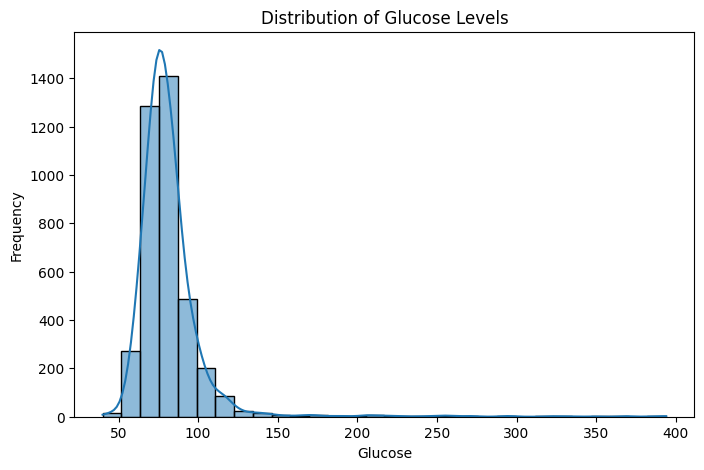

In [12]:
#Distribution of Glucose
plt.figure(figsize=(8,5))
sns.histplot(df['glucose'], bins=30, kde=True)

plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#VISUALIZE THE DISTRIBUTION OF GLUCOSE AND HEALTH INDICATORS

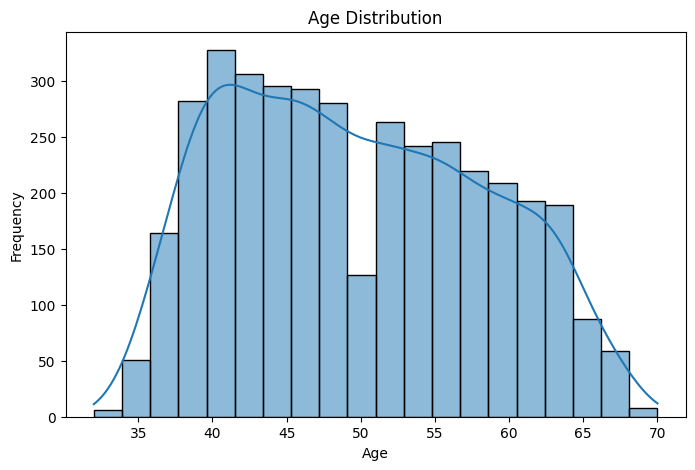

In [13]:
#Distribution of Age
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

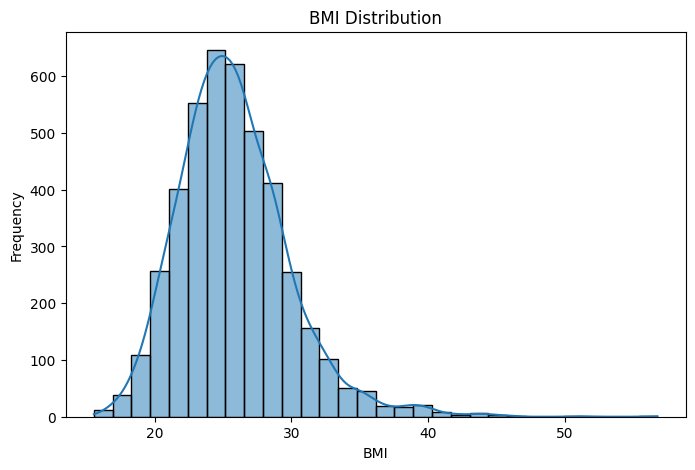

In [19]:
#BMI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], bins=30, kde=True)

plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

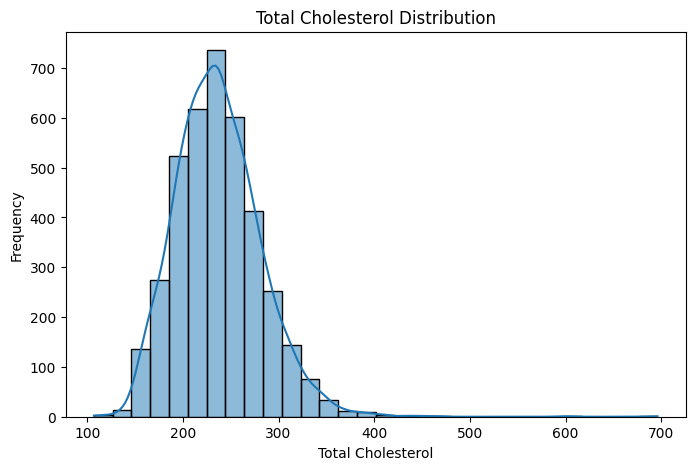

In [14]:
#Total Cholesterol Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['totChol'], bins=30, kde=True)

plt.title('Total Cholesterol Distribution')
plt.xlabel('Total Cholesterol')
plt.ylabel('Frequency')
plt.show()

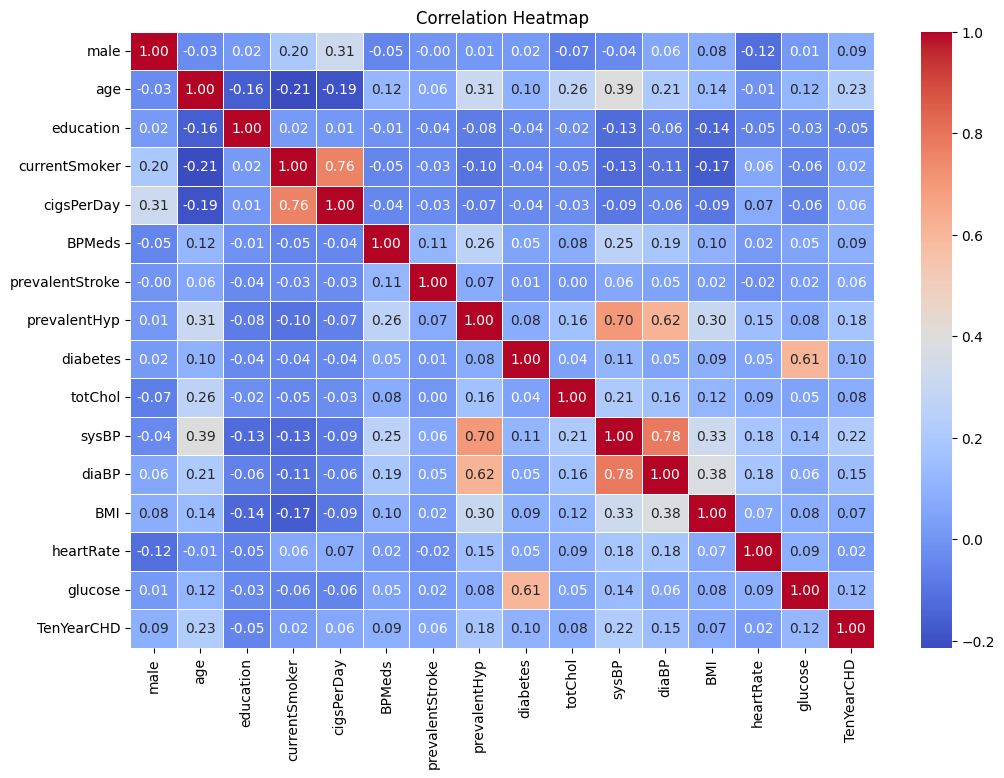

In [21]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

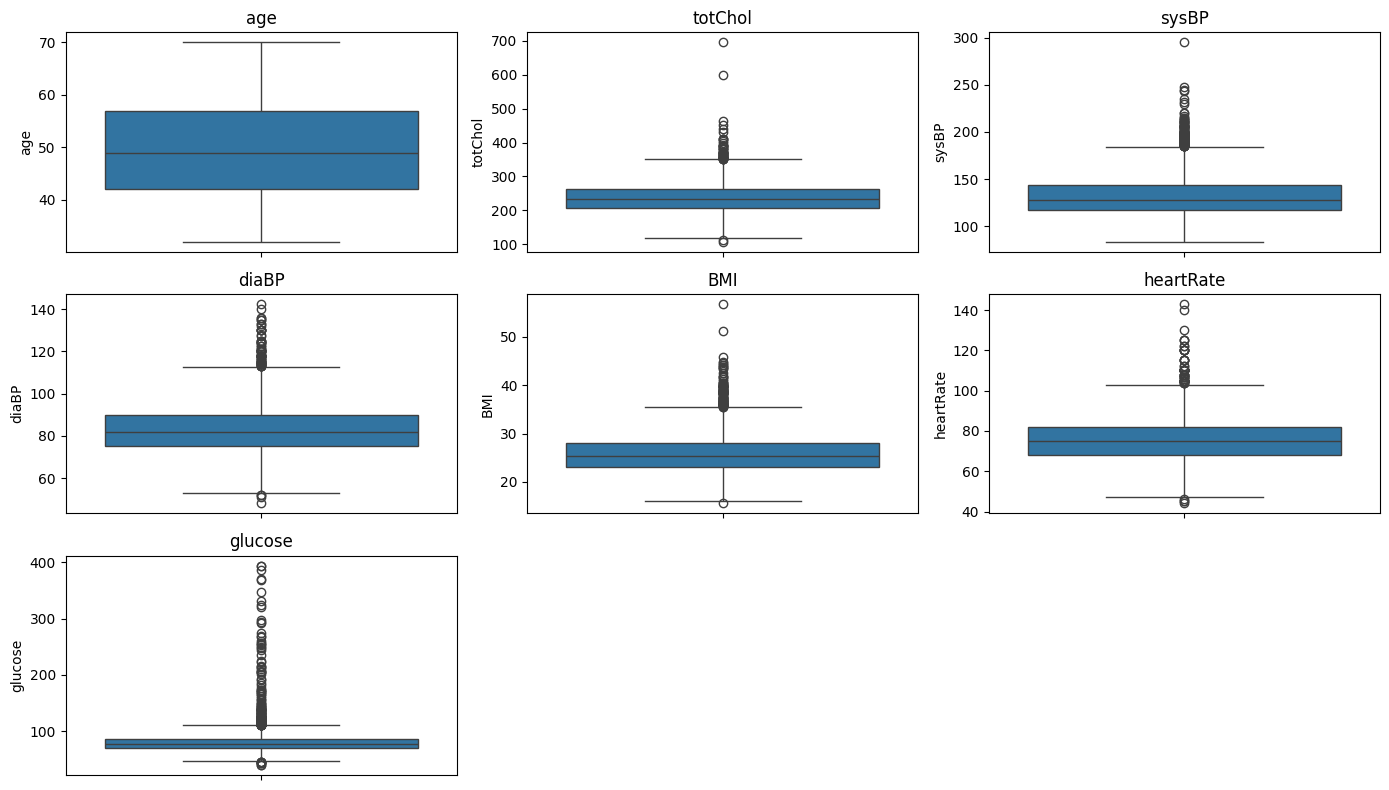

In [15]:
#Boxplots (Outlier Detection)
numeric_cols = ['age','totChol','sysBP','diaBP','BMI','heartRate','glucose']

plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

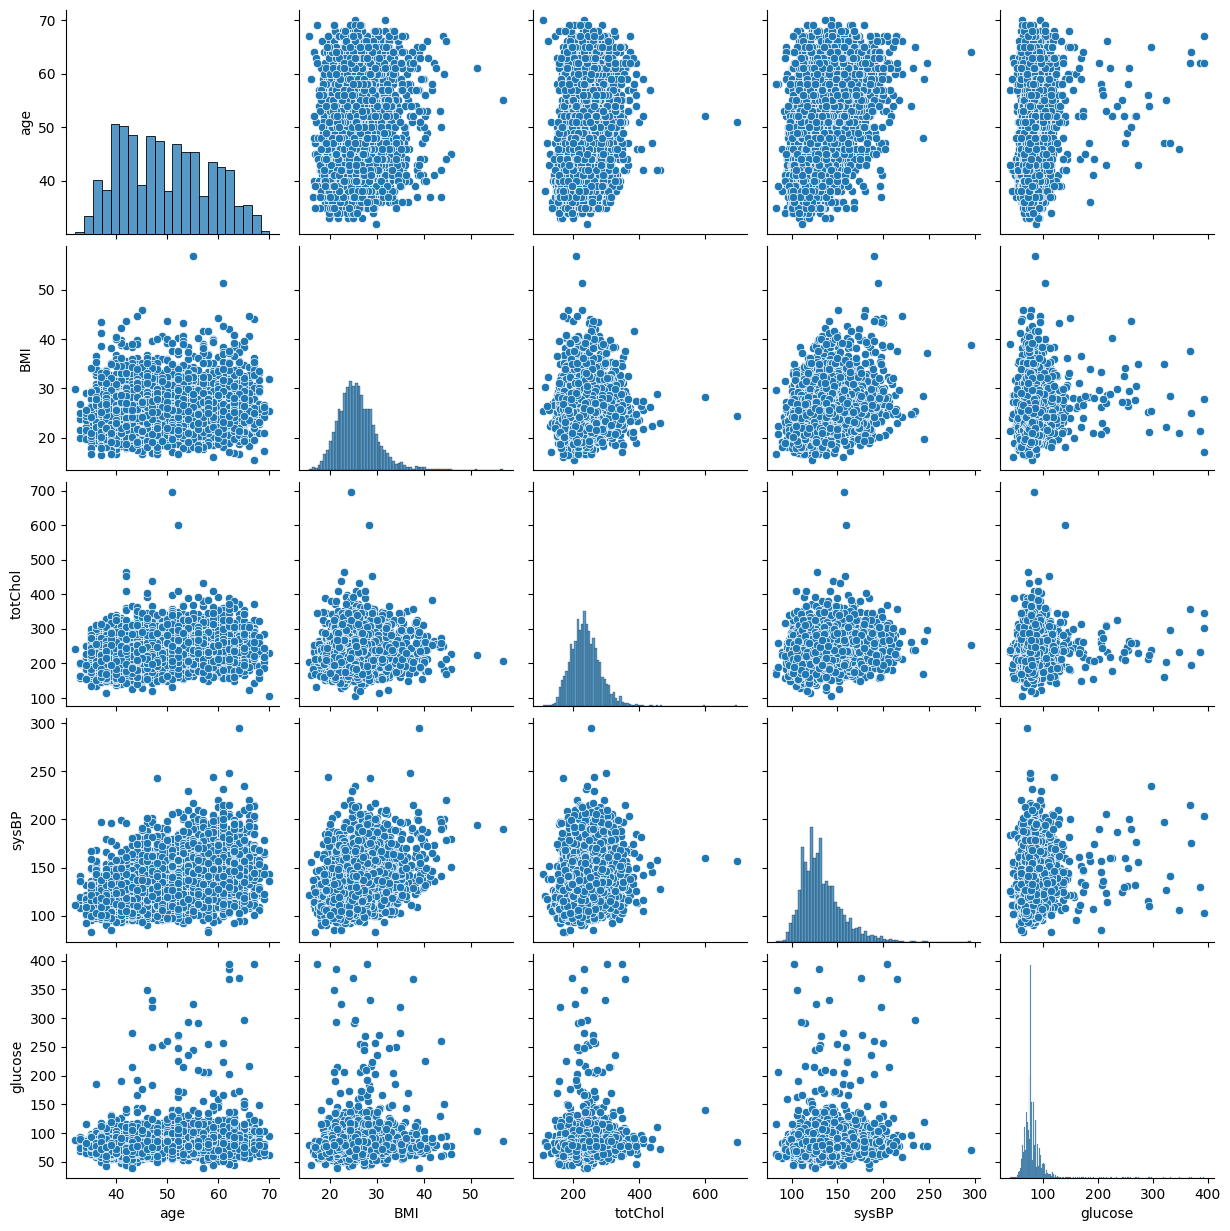

In [24]:
#Pairplot (Relationships)

selected = ['age','BMI','totChol','sysBP','glucose']

sns.pairplot(df[selected])

plt.show()

In [ ]:
#PERFORM FEATURE SELECTION AND ENGINEERING 

In [ ]:
# Feature Engineering and Data Preparation
The dataset is prepared for machine learning by separating the input features from the target variable. 
The data is then divided into training and testing sets to enable unbiased model evaluation. 
Finally, feature scaling is applied using StandardScaler to standardize numerical variables and improve the performance of machine learning algorithms.

In [16]:
#4.1 Select Relevant Features
# Selecting input features
X = df.drop(columns=['glucose'])

# Target variable
y = df['glucose']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3852, 15)
Target shape: (3852,)


In [23]:
#4.2 Feature Engineering (Create a Classification Target)
# Creating binary glucose class
df['HighGlucose'] = (df['glucose'] >= 126).astype(int)

# Check class distribution
print(df['HighGlucose'].value_counts())

HighGlucose
0    3766
1      86
Name: count, dtype: int64


In [24]:
#Updating Features and Target
X = df.drop(columns=['glucose', 'HighGlucose'])

# Target
y = df['HighGlucose']

print(X.shape)
print(y.shape)

(3852, 15)
(3852,)


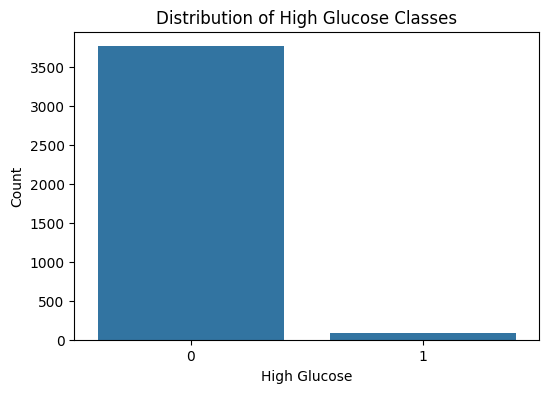

In [25]:
#Checking Class Balance
plt.figure(figsize=(6,4))
sns.countplot(x=y)

plt.title("Distribution of High Glucose Classes")
plt.xlabel("High Glucose")
plt.ylabel("Count")

plt.show()

In [36]:
#Correlation-Based Feature Selection
corr = df.corr(numeric_only=True)

glucose_corr = corr['glucose'].sort_values(ascending=False)

print(glucose_corr)

glucose            1.000000
HighGlucose        0.723525
diabetes           0.617630
sysBP              0.140573
TenYearCHD         0.125590
age                0.122356
heartRate          0.094539
prevalentHyp       0.086656
BMI                0.086303
diaBP              0.061075
BPMeds             0.050984
totChol            0.046452
prevalentStroke    0.018440
male               0.005979
education         -0.035410
currentSmoker     -0.056726
cigsPerDay        -0.059399
Name: glucose, dtype: float64


In [37]:
#Select the Most Relevant Features
selected_features = [
    'diabetes',
    'sysBP',
    'age',
    'heartRate',
    'prevalentHyp',
    'BMI',
    'diaBP',
    'BPMeds',
    'totChol',
    'TenYearCHD'
]

X = df[selected_features]
y = df['HighGlucose']

In [39]:
#Scale the Features
print("Selected Features:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Selected Features:
['diabetes', 'sysBP', 'age', 'heartRate', 'prevalentHyp', 'BMI', 'diaBP', 'BPMeds', 'totChol', 'TenYearCHD']

Shape of X: (3852, 10)
Shape of y: (3852,)


In [ ]:
#TRAIN MACHINE LEARNING MODELS

In [ ]:
## Model Training
Several supervised machine learning algorithms are trained using the standardized training dataset.
Training multiple models enables a comprehensive comparison of their predictive performance and helps identify the most suitable algorithm for glucose level prediction.

In [47]:
#Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (3081, 10)
Testing set : (771, 10)


In [52]:
#Train Logistic Regression
# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

lr.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
#Evaluate models using classification metrics.


In [53]:
#Evaluate Logistic Regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.940337224383917
Precision: 0.2542372881355932
Recall   : 0.8823529411764706
F1 Score : 0.39473684210526316

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       754
           1       0.25      0.88      0.39        17

    accuracy                           0.94       771
   macro avg       0.63      0.91      0.68       771
weighted avg       0.98      0.94      0.96       771



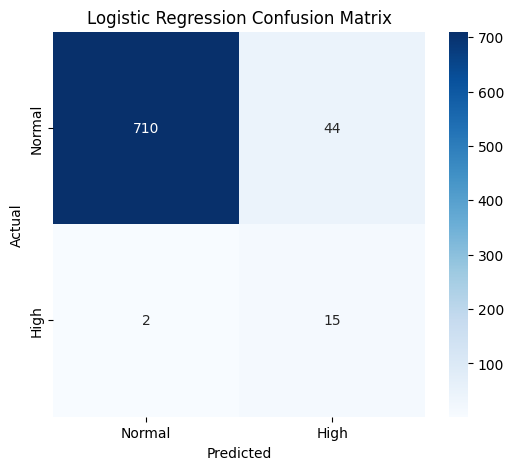

In [54]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Normal','High'],
            yticklabels=['Normal','High'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [83]:
#ROC Curve and ROC-AUC Analysis

# Probability of the positive class
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9585738804805742


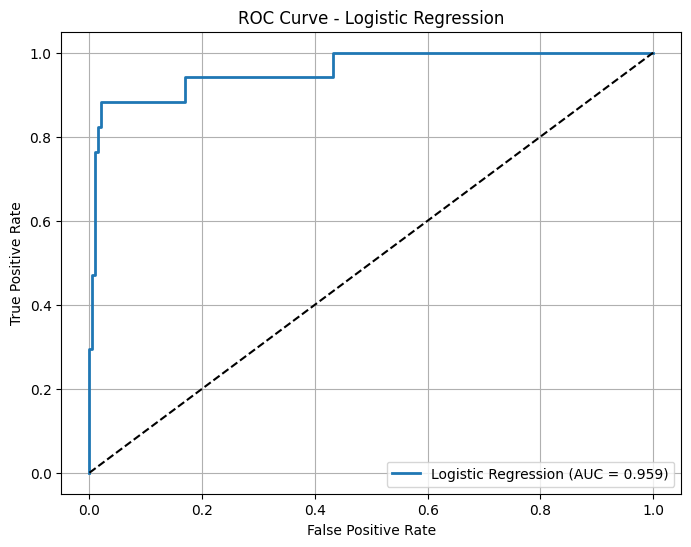

In [84]:
#ROC Curve and ROC-AUC Analysis
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})',
    linewidth=2
)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
#DECISION TREE

In [55]:
#Training the Decision Tree
# Train Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

In [ ]:
#Evaluate models using classification metrics.


In [56]:
#6.2. Evaluating the Decision Tree
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.9610894941634242
Precision: 0.21739130434782608
Recall   : 0.29411764705882354
F1 Score : 0.25

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       754
           1       0.22      0.29      0.25        17

    accuracy                           0.96       771
   macro avg       0.60      0.64      0.62       771
weighted avg       0.97      0.96      0.96       771



In [ ]:
#RANDOM FOREST

In [ ]:
#Evaluate models using classification metrics.


In [96]:
#Training the Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
# Predictions
y_pred_rf = rf.predict(X_test)

In [90]:
# Retraining
selected_features = [
    'diabetes',
    'sysBP',
    'age',
    'heartRate',
    'prevalentHyp',
    'BMI',
    'diaBP',
    'BPMeds',
    'totChol',
    'TenYearCHD'
]

X = df[selected_features]
y = df['HighGlucose']

In [91]:
#Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [92]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [93]:
#Training the Random Forest again
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
#PREDICT GLUCOSE LEVELS AND DRAW INSIGHTS.

In [ ]:
# Model Evaluation
The trained models are evaluated using appropriate performance metrics to assess their predictive capabilities. 
Predictions generated on the testing dataset are compared with the actual values to determine the effectiveness of each model and identify the best-performing approach.

In [70]:
# Remaking predictions using the Random Forest model
y_pred = rf.predict(X_test)

In [71]:
print(comparison['Predicted'].value_counts())

Predicted
0    761
1     10
Name: count, dtype: int64


In [72]:
print(comparison['Actual'].value_counts())

Actual
0    754
1     17
Name: count, dtype: int64


In [73]:
comparison[(comparison['Actual'] == 1) | (comparison['Predicted'] == 1)]

,Actual,Predicted
27,1,0
45,1,0
64,1,0
87,1,0
93,1,0
156,1,1
209,1,0
235,1,0
255,1,0
258,0,1


In [ ]:
#VISUALIZE THE MODEL'S IMPORTANT FEATURES AND PERFORMANCE.

In [125]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

In [126]:
print(X.shape)
print(X.columns.tolist())

(3852, 16)
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'HighGlucose']


In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:
print(X_train.shape)
print(X_test.shape)

(3081, 16)
(771, 16)


In [129]:

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [130]:
print(len(X.columns))
print(rf.n_features_in_)
print(len(rf.feature_importances_))

16
16
16


In [76]:
#feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

        Feature  Importance
0      diabetes    0.421529
5           BMI    0.100596
8       totChol    0.093963
3     heartRate    0.090000
2           age    0.086127
1         sysBP    0.086097
6         diaBP    0.061669
9    TenYearCHD    0.049015
4  prevalentHyp    0.010097
7        BPMeds    0.000906


In [131]:
rf.feature_names_in_

array(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
       'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol',
       'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'HighGlucose'],
      dtype=object)

In [132]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [133]:
print(rf.n_features_in_)
print(rf.feature_names_in_)

16
['male' 'age' 'education' 'currentSmoker' 'cigsPerDay' 'BPMeds'
 'prevalentStroke' 'prevalentHyp' 'diabetes' 'totChol' 'sysBP' 'diaBP'
 'BMI' 'heartRate' 'glucose' 'HighGlucose']


In [ ]:
# visualisation

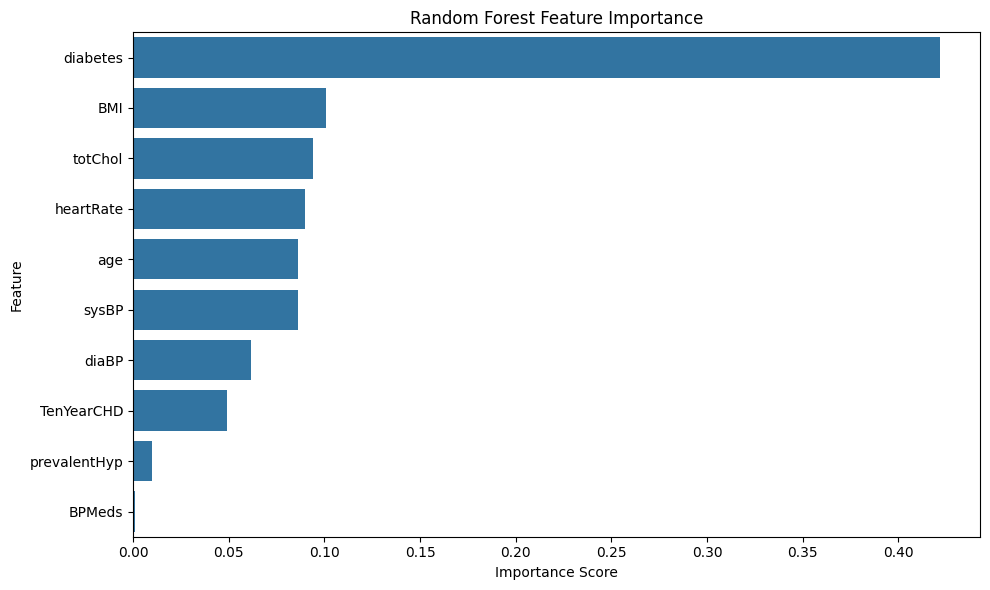

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
#EXPLAINABLE AI

In [ ]:
#Permutation Feature Importance

In [134]:
#Calculating Importance
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

In [135]:
#Create DataFrame
permutation_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

permutation_importance_df = permutation_importance_df.sort_values(
    by='Importance',
    ascending=False
)

permutation_importance_df.head()

,Feature,Importance
4,cigsPerDay,0.002205
10,sysBP,0.001556
6,prevalentStroke,0.001297
1,age,0.000649
2,education,0.000519


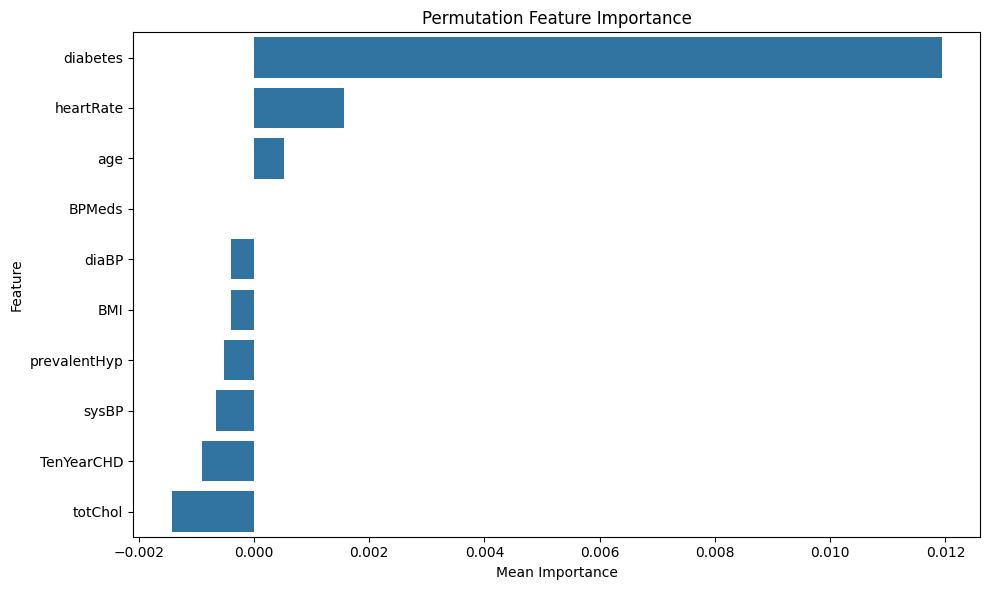

In [108]:
#Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=permutation_importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Permutation Feature Importance")

plt.xlabel("Mean Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [ ]:
#Partial Dependence Plots (PDP)

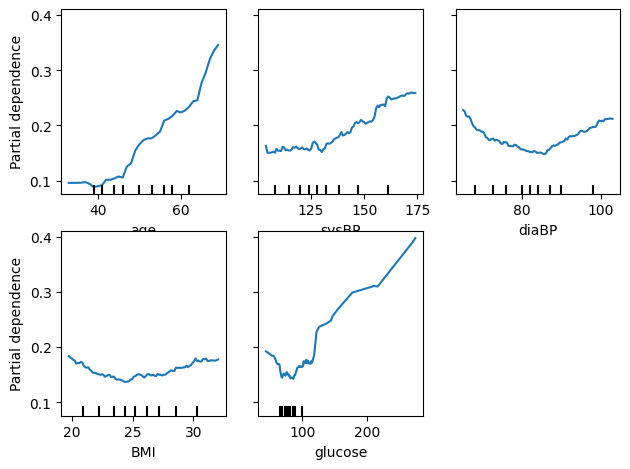

In [141]:
features = [
    'age',
    'sysBP',
    'diaBP',
    'BMI',
    'glucose'
]

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features
)

plt.tight_layout()
plt.show()

In [ ]:
#SHAP

In [ ]:
#Import SHAP


In [146]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

In [147]:
shap_values

.values =
array([[[ 0.02440663, -0.02440663],
        [-0.04009164,  0.04009164],
        [ 0.01530895, -0.01530895],
        ...,
        [ 0.01975866, -0.01975866],
        [ 0.02254196, -0.02254196],
        [ 0.0019579 , -0.0019579 ]],

       [[-0.01640259,  0.01640259],
        [ 0.03126382, -0.03126382],
        [-0.00690016,  0.00690016],
        ...,
        [-0.00078802,  0.00078802],
        [-0.03172446,  0.03172446],
        [ 0.00135581, -0.00135581]],

       [[ 0.00027617, -0.00027617],
        [-0.0677914 ,  0.0677914 ],
        [-0.0008489 ,  0.0008489 ],
        ...,
        [-0.01428186,  0.01428186],
        [-0.0077189 ,  0.0077189 ],
        [ 0.00148495, -0.00148495]],

       ...,

       [[-0.03879189,  0.03879189],
        [-0.09170078,  0.09170078],
        [ 0.00312333, -0.00312333],
        ...,
        [ 0.0086145 , -0.0086145 ],
        [ 0.00686321, -0.00686321],
        [ 0.0015652 , -0.0015652 ]],

       [[-0.01457852,  0.01457852],
        [ 0.03529

In [149]:
shap_values_class1 = shap_values[:, :, 1]

In [150]:
shap_values_class1.shape

(771, 16)

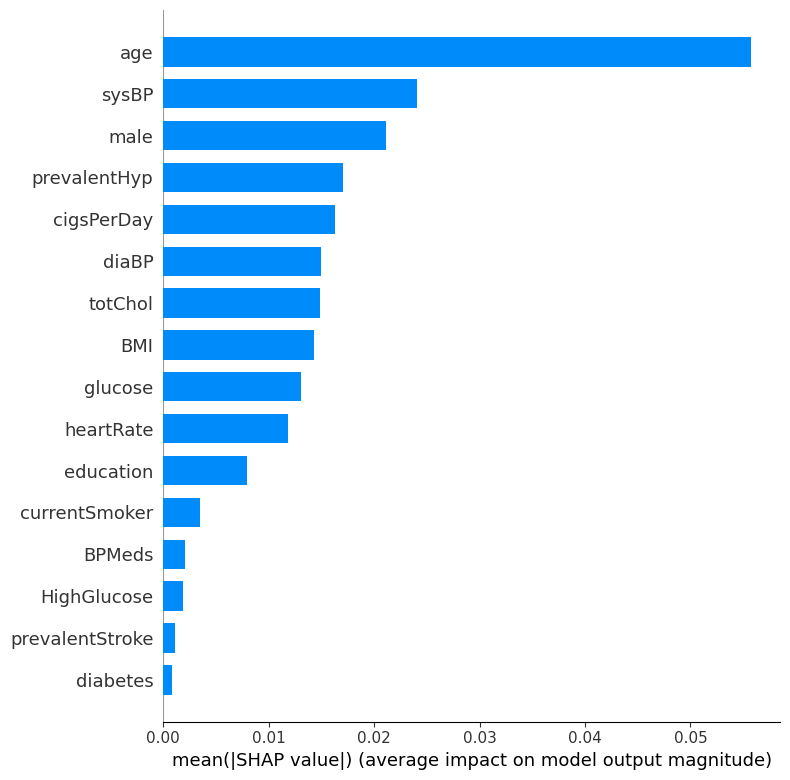

In [151]:
#SHAP Feature Importance (Bar Plot)
shap.summary_plot(
    shap_values_class1,
    X_test,
    plot_type="bar"
)

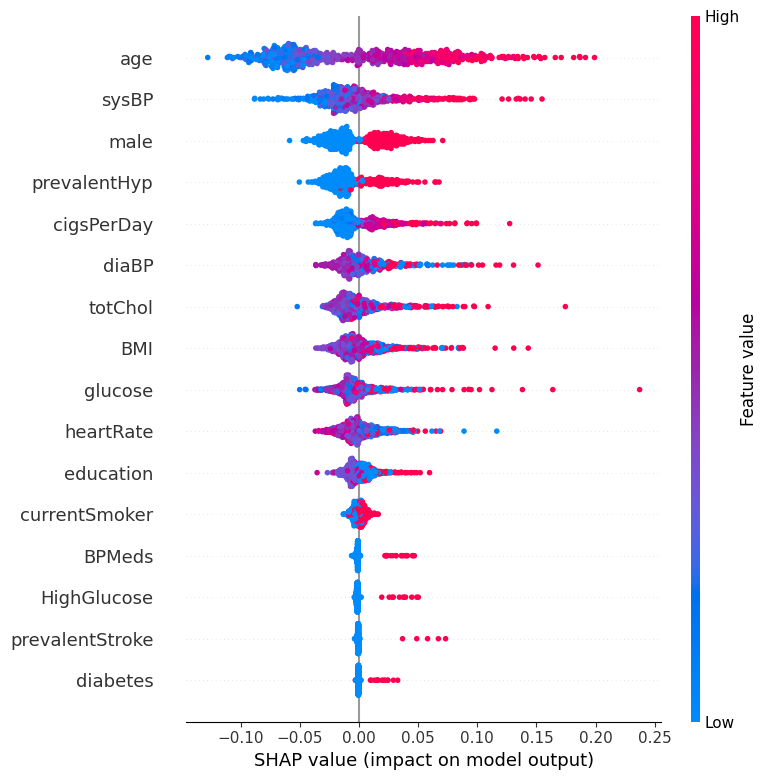

In [153]:
#SHAP Feature Importance (Bar Plot)
shap.summary_plot(
    shap_values_class1,
    X_test
)

In [155]:
#Individual Patient Explanation (Waterfall Plot)
sample_index = 0

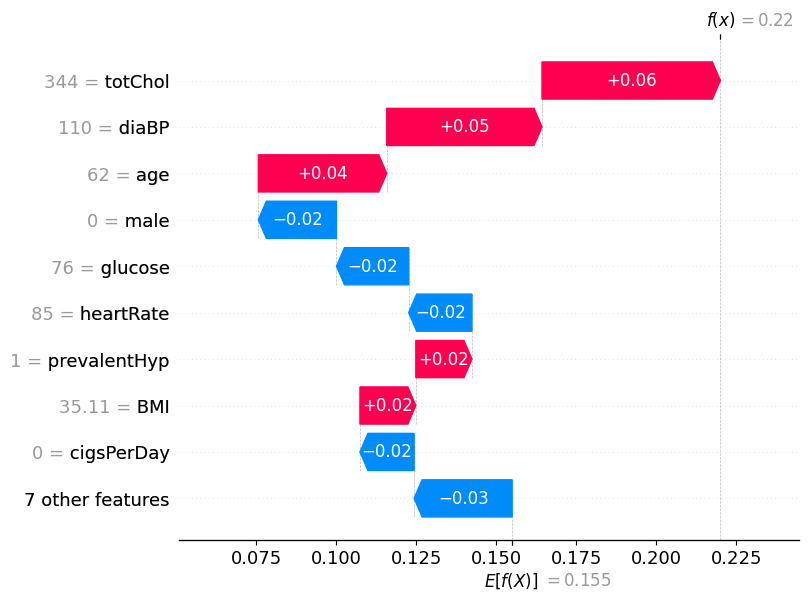

In [156]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_class1[sample_index],
        base_values=shap_values.base_values[sample_index, 1],
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

In [ ]:
#LIME Explainer

In [159]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Heart Disease', 'Heart Disease'],
    mode='classification',
    random_state=42
)

In [160]:
sample_index = 0
sample = X_test.iloc[sample_index]

In [161]:
print(sample)

male                 0.00
age                 62.00
education            2.00
currentSmoker        0.00
cigsPerDay           0.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         1.00
diabetes             0.00
totChol            344.00
sysBP              154.00
diaBP              110.00
BMI                 35.11
heartRate           85.00
glucose             76.00
HighGlucose          0.00
Name: 1837, dtype: float64


In [164]:
#function for LIME
def predict_proba_lime(data):
    data = pd.DataFrame(data, columns=X_train.columns)
    return rf.predict_proba(data)

In [166]:
#Generating LIME Explanation
lime_explanation = explainer_lime.explain_instance(
    data_row=sample.values,
    predict_fn=predict_proba_lime,
    num_features=10
)

In [171]:
lime_explanation.as_list()

[('age > 56.00', 0.09654114712046372),
 ('sysBP > 144.00', 0.06463402483507946),
 ('0.00 < prevalentHyp <= 1.00', 0.04897365393354997),
 ('prevalentStroke <= 0.00', -0.04099633864993005),
 ('diaBP > 90.00', 0.03760110935873863),
 ('BPMeds <= 0.00', -0.03215321554626704),
 ('male <= 0.00', -0.03167123441345082),
 ('HighGlucose <= 0.00', -0.03009461492600901),
 ('cigsPerDay <= 0.00', -0.029532918373392978),
 ('totChol > 265.00', 0.02824824163262765)]

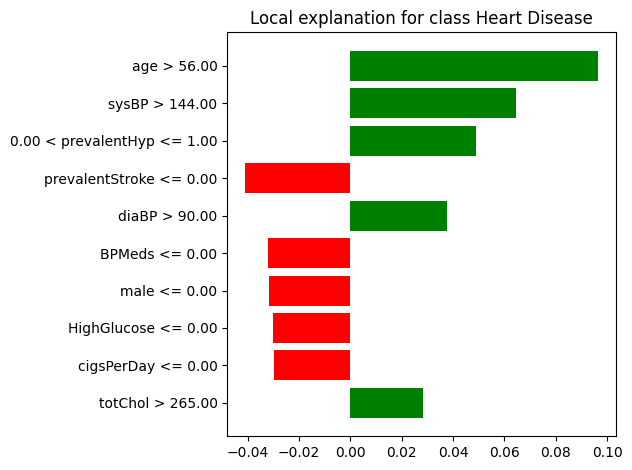

In [170]:
lime_explanation.as_pyplot_figure()

import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

In [ ]:
## Conclusion
This project developed an AI-based machine learning system for predicting blood glucose levels using clinical and lifestyle-related features from the Framingham Heart Study dataset.
The notebook presented an end-to-end machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, prediction, and evaluation. Machine learning techniques were applied to identify patterns and relationships between patient characteristics and glucose levels, enabling the development of a predictive healthcare analytics solution.
The developed AI model demonstrates the potential of machine learning in estimating glucose levels and supporting early identification of abnormal blood glucose patterns. By analyzing important health-related factors, the system provides insights into the variables associated with glucose variations and highlights the role of data-driven approaches in healthcare applications.
The results show that artificial intelligence can be effectively utilized for predictive healthcare analytics by transforming clinical data into meaningful insights. 
Such systems can support healthcare professionals in monitoring risk factors and improving decision-making processes.
Future improvements could include exploring advanced machine learning and deep learning algorithms, optimizing model performance through hyperparameter tuning, incorporating larger and more diverse healthcare datasets, and applying Explainable AI techniques to improve model transparency and interpretability.